# Model Evaluation
**UPI Transaction Analytics & Risk Monitoring Platform**

Evaluates model performance: ROC curves, confusion matrix, feature importance, and the cumulative fraud capture curve.

> Run `main.py` first to generate `reports/risk_scored_transactions.csv` and trained models

In [2]:
%pip install --quiet scikit-learn joblib pandas numpy matplotlib

Note: you may need to restart the kernel to use updated packages.


In [3]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from sklearn.metrics import (
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)

%matplotlib inline
plt.rcParams.update({
    'figure.facecolor': '#0D1117', 'axes.facecolor': '#161B22',
    'axes.edgecolor': '#30363D',   'axes.labelcolor': '#C9D1D9',
    'xtick.color': '#8B949E',      'ytick.color': '#8B949E',
    'text.color': '#C9D1D9',       'grid.color': '#21262D',
    'grid.alpha': 0.6,             'legend.facecolor': '#161B22',
    'legend.edgecolor': '#30363D', 'font.family': 'DejaVu Sans',
    'font.size': 11, 'axes.titlesize': 13, 'axes.titleweight': 'bold',
})
PALETTE = {
    'fraud': '#FF4757', 'legit': '#2ED573', 'medium': '#FFA502',
    'accent': '#1E90FF', 'purple': '#A855F7', 'teal': '#00BCD4',
    'bg_dark': '#0D1117', 'bg_card': '#161B22', 'border': '#30363D', 'text_muted': '#8B949E',
}

# Load risk-scored test results
test_scores = pd.read_csv('../reports/risk_scored_transactions.csv')
y_test = test_scores['isFraud'].values
y_prob = test_scores['ml_fraud_prob'].values
y_pred = (y_prob >= 0.5).astype(int)

# Load feature importance from saved RF model
FEATURE_COLS = joblib.load('../models/feature_cols.pkl')
rf_model     = joblib.load('../models/random_forest.pkl')
feat_imp     = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

print(f"Test set: {len(test_scores):,} rows  |  Fraud: {y_test.sum():,}  ({y_test.mean()*100:.4f}%)")
print(f"Loaded Random Forest: {rf_model.n_estimators} trees")

Test set: 8,883 rows  |  Fraud: 7  (0.0788%)
Loaded Random Forest: 300 trees


## 1. ROC & Precision-Recall Curves

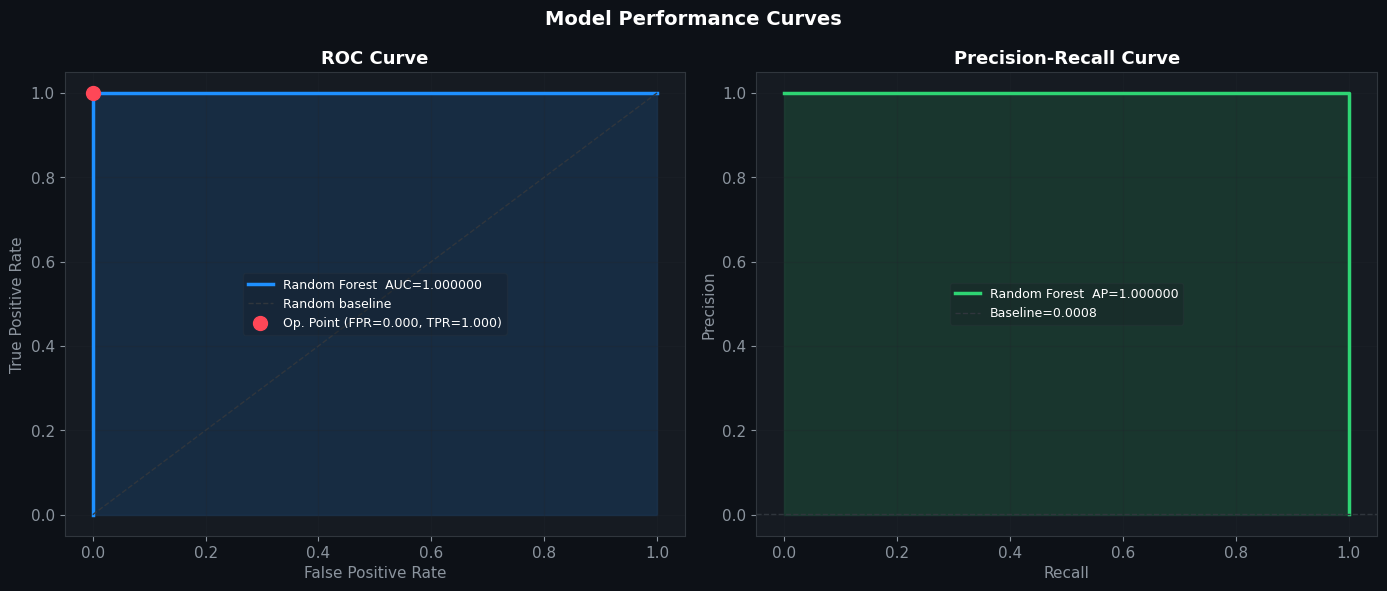


ROC-AUC: 1.000000  |  Average Precision: 1.000000


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor=PALETTE['bg_dark'])
fig.suptitle('Model Performance Curves', fontsize=14, fontweight='bold', color='white')

# ROC Curve
ax = axes[0]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
ax.plot(fpr, tpr, color=PALETTE['accent'], linewidth=2.5, label=f'Random Forest  AUC={auc:.6f}')
ax.fill_between(fpr, tpr, alpha=0.15, color=PALETTE['accent'])
ax.plot([0,1],[0,1],'--', color=PALETTE['border'], linewidth=1, label='Random baseline')
op_idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[op_idx], tpr[op_idx], s=100, color=PALETTE['fraud'], zorder=5, label=f'Op. Point (FPR={fpr[op_idx]:.3f}, TPR={tpr[op_idx]:.3f})')
ax.set_title('ROC Curve', color='white')
ax.set_xlabel('False Positive Rate', color=PALETTE['text_muted'])
ax.set_ylabel('True Positive Rate', color=PALETTE['text_muted'])
ax.legend(labelcolor='white', framealpha=0.3, fontsize=9)
ax.grid(alpha=0.3)

# Precision-Recall Curve
ax = axes[1]
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)
ax.plot(rec, prec, color=PALETTE['legit'], linewidth=2.5, label=f'Random Forest  AP={ap:.6f}')
ax.fill_between(rec, prec, alpha=0.15, color=PALETTE['legit'])
baseline = y_test.mean()
ax.axhline(baseline, linestyle='--', color=PALETTE['border'], linewidth=1, label=f'Baseline={baseline:.4f}')
ax.set_title('Precision-Recall Curve', color='white')
ax.set_xlabel('Recall', color=PALETTE['text_muted'])
ax.set_ylabel('Precision', color=PALETTE['text_muted'])
ax.legend(labelcolor='white', framealpha=0.3, fontsize=9)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\nROC-AUC: {auc:.6f}  |  Average Precision: {ap:.6f}")

## 2. Confusion Matrix & Score Distribution

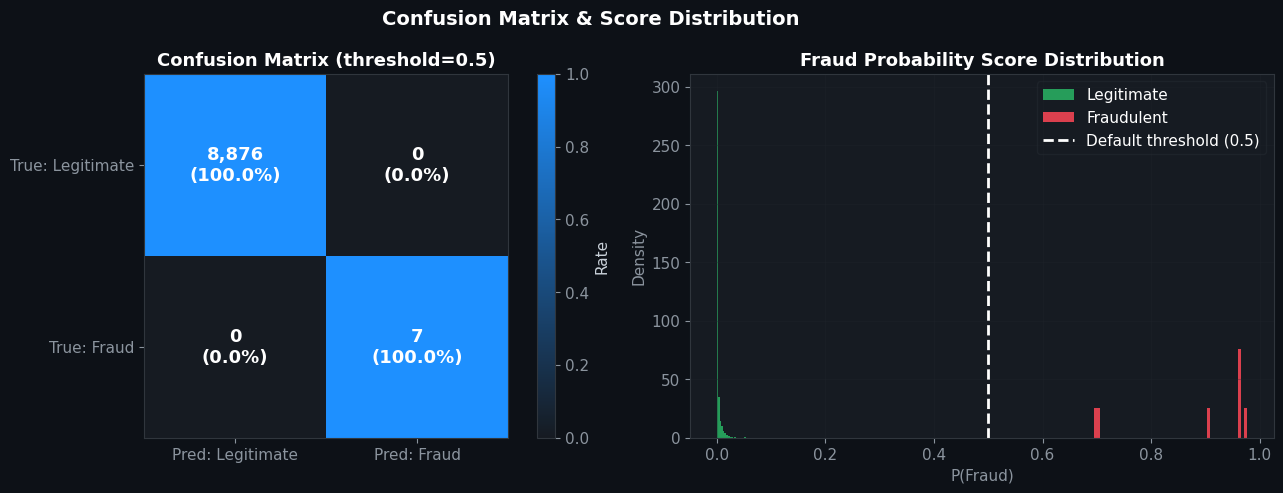


Accuracy=1.0000  Precision=1.0000  Recall=1.0000  F1=1.0000
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      8876
       Fraud       1.00      1.00      1.00         7

    accuracy                           1.00      8883
   macro avg       1.00      1.00      1.00      8883
weighted avg       1.00      1.00      1.00      8883



In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

cm      = confusion_matrix(y_test, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=PALETTE['bg_dark'])
fig.suptitle('Confusion Matrix & Score Distribution', fontsize=14, fontweight='bold', color='white')

ax = axes[0]
cmap_cm = LinearSegmentedColormap.from_list('cm', [PALETTE['bg_card'], PALETTE['accent']])
im = ax.imshow(cm_norm, cmap=cmap_cm, vmin=0, vmax=1)
for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i,j]:,}\n({cm_norm[i,j]*100:.1f}%)',
                ha='center', va='center', color='white', fontsize=13, fontweight='bold')
ax.set_xticks([0,1]); ax.set_yticks([0,1])
ax.set_xticklabels(['Pred: Legitimate','Pred: Fraud'])
ax.set_yticklabels(['True: Legitimate','True: Fraud'])
ax.set_title('Confusion Matrix (threshold=0.5)', color='white')
plt.colorbar(im, ax=ax, fraction=0.04, label='Rate')

ax = axes[1]
ax.hist(y_prob[y_test==0], bins=50, alpha=0.7, color=PALETTE['legit'],
        label='Legitimate', density=True, edgecolor='none')
ax.hist(y_prob[y_test==1], bins=50, alpha=0.85, color=PALETTE['fraud'],
        label='Fraudulent', density=True, edgecolor='none')
ax.axvline(0.5, color='white', linestyle='--', linewidth=2, label='Default threshold (0.5)')
ax.set_title('Fraud Probability Score Distribution', color='white')
ax.set_xlabel('P(Fraud)', color=PALETTE['text_muted'])
ax.set_ylabel('Density', color=PALETTE['text_muted'])
ax.legend(labelcolor='white', framealpha=0.3)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)
f1   = f1_score(y_test, y_pred, zero_division=0)
print(f"\nAccuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}")
print(classification_report(y_test, y_pred, target_names=['Legitimate','Fraud']))

## 3. Feature Importances — What Drives Fraud Predictions?

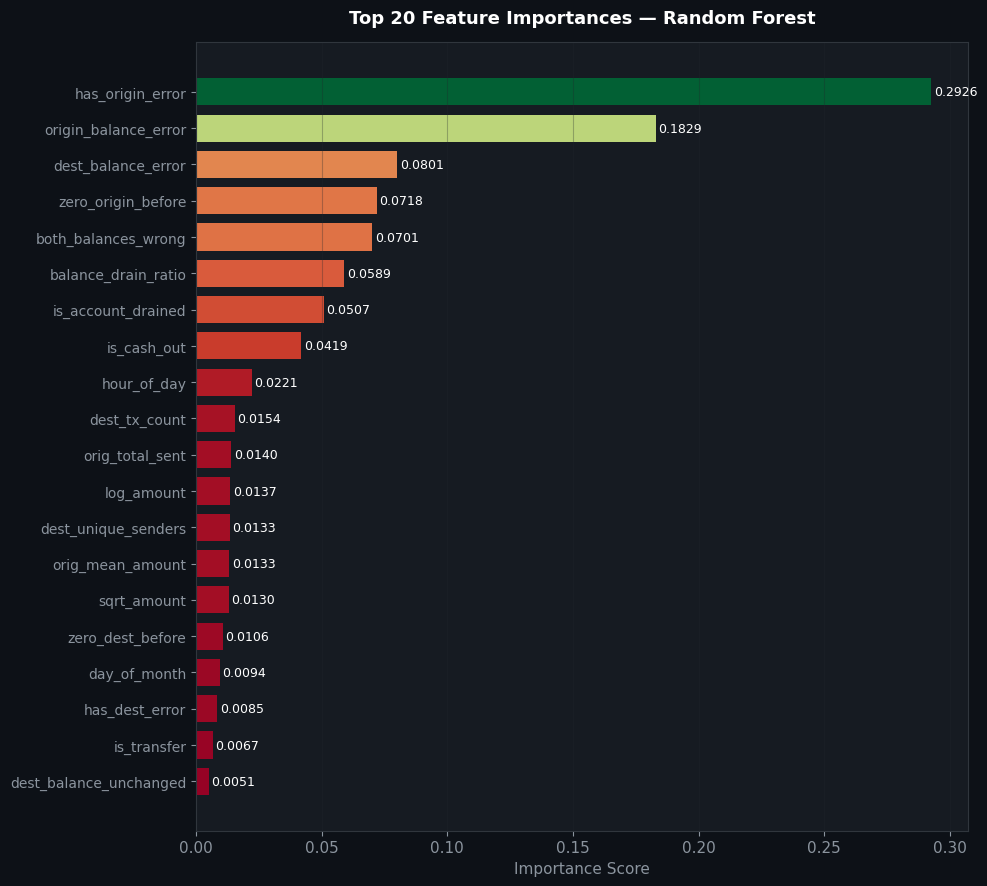

In [6]:
fig, ax = plt.subplots(figsize=(10, 9), facecolor=PALETTE['bg_dark'])
top20 = feat_imp.head(20).sort_values()
norm_imp = (top20.values - top20.values.min()) / (top20.values.max() - top20.values.min() + 1e-9)
bar_colors = plt.cm.RdYlGn(norm_imp)
bars = ax.barh(range(len(top20)), top20.values, color=bar_colors, alpha=0.9, height=0.75)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=10)
for bar, val in zip(bars, top20.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, color='white')
ax.set_title('Top 20 Feature Importances — Random Forest', color='white', pad=14)
ax.set_xlabel('Importance Score', color=PALETTE['text_muted'])
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Cumulative Fraud Capture Curve

This shows the efficiency of the risk model: review the top X% by risk score → capture Y% of all fraud.

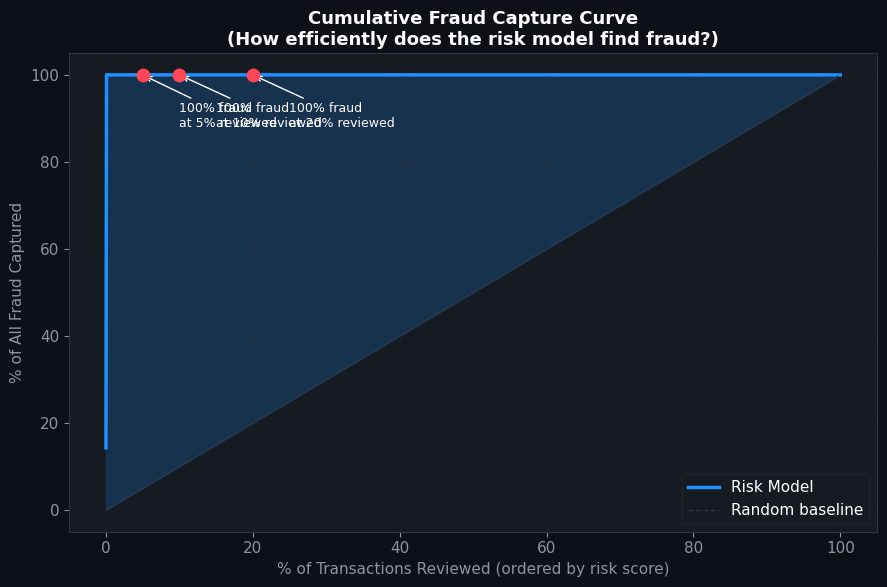

In [7]:
fig, ax = plt.subplots(figsize=(9, 6), facecolor=PALETTE['bg_dark'])

sorted_df   = test_scores.sort_values('risk_score', ascending=False)
cum_fraud   = sorted_df['isFraud'].cumsum()
cum_total   = np.arange(1, len(sorted_df)+1)
capture_rt  = cum_fraud / max(y_test.sum(), 1)
review_rt   = cum_total / len(sorted_df)

ax.plot(review_rt*100, capture_rt*100, color=PALETTE['accent'], linewidth=2.5, label='Risk Model')
ax.plot([0,100],[0,100], '--', color=PALETTE['border'], linewidth=1, label='Random baseline')
ax.fill_between(review_rt*100, capture_rt*100, review_rt*100, alpha=0.2, color=PALETTE['accent'])

for review_pct in [5, 10, 20]:
    idx = int(len(review_rt) * review_pct/100)
    captured = capture_rt.iloc[idx]*100
    ax.scatter(review_pct, captured, s=80, color=PALETTE['fraud'], zorder=5)
    ax.annotate(f'{captured:.0f}% fraud\nat {review_pct}% reviewed',
                xy=(review_pct, captured),
                xytext=(review_pct+5, captured-12),
                color='white', fontsize=9,
                arrowprops=dict(arrowstyle='->', color='white', lw=1))

ax.set_title('Cumulative Fraud Capture Curve\n(How efficiently does the risk model find fraud?)', color='white')
ax.set_xlabel('% of Transactions Reviewed (ordered by risk score)', color=PALETTE['text_muted'])
ax.set_ylabel('% of All Fraud Captured', color=PALETTE['text_muted'])
ax.legend(labelcolor='white', framealpha=0.3)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Risk Engine Score Distribution & Level Breakdown

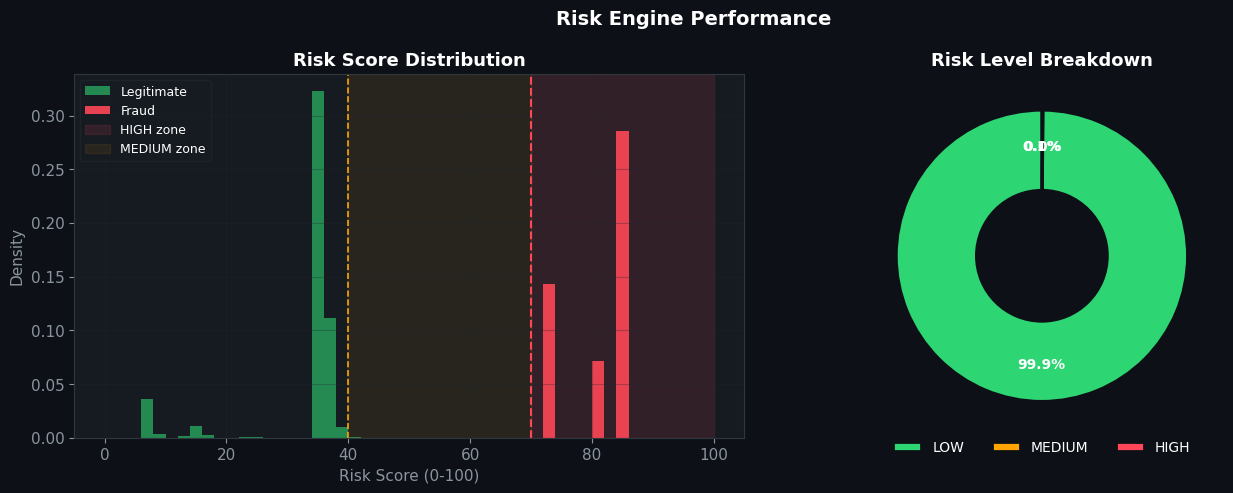


Risk Level Effectiveness:
  HIGH    :      7 txns | Fraud:    7 (100.00%)
  MEDIUM  :      4 txns | Fraud:    0 (0.00%)
  LOW     :  8,872 txns | Fraud:    0 (0.00%)


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), facecolor=PALETTE['bg_dark'])
fig.suptitle('Risk Engine Performance', fontsize=14, fontweight='bold', color='white')

ax = axes[0]
bins_risk = np.linspace(0, 100, 51)
ax.hist(test_scores[test_scores['isFraud']==0]['risk_score'],
        bins=bins_risk, alpha=0.6, color=PALETTE['legit'], density=True, label='Legitimate')
ax.hist(test_scores[test_scores['isFraud']==1]['risk_score'],
        bins=bins_risk, alpha=0.9, color=PALETTE['fraud'], density=True, label='Fraud')
ax.axvspan(70, 100, alpha=0.12, color=PALETTE['fraud'],  label='HIGH zone')
ax.axvspan(40, 70,  alpha=0.08, color=PALETTE['medium'], label='MEDIUM zone')
ax.axvline(70, color=PALETTE['fraud'],  linestyle='--', linewidth=1.5)
ax.axvline(40, color=PALETTE['medium'], linestyle='--', linewidth=1.2)
ax.set_title('Risk Score Distribution', color='white')
ax.set_xlabel('Risk Score (0-100)', color=PALETTE['text_muted'])
ax.set_ylabel('Density', color=PALETTE['text_muted'])
ax.legend(labelcolor='white', framealpha=0.3, fontsize=9)
ax.grid(alpha=0.3)

ax = axes[1]
level_counts = test_scores['risk_level'].value_counts().reindex(['LOW','MEDIUM','HIGH']).fillna(0)
rl_colors = [PALETTE['legit'], PALETTE['medium'], PALETTE['fraud']]
wedges, _, autotexts = ax.pie(
    level_counts.values, colors=rl_colors, startangle=90,
    wedgeprops=dict(width=0.55, edgecolor=PALETTE['bg_dark'], linewidth=2),
    autopct='%1.1f%%', pctdistance=0.75
)
for at in autotexts: at.set(color='white', fontsize=10, fontweight='bold')
ax.legend(['LOW','MEDIUM','HIGH'], loc='lower center', bbox_to_anchor=(0.5,-0.08),
          ncol=3, labelcolor='white', framealpha=0, fontsize=10)
ax.set_title('Risk Level Breakdown', color='white')

plt.tight_layout()
plt.show()

print("\nRisk Level Effectiveness:")
for level in ['HIGH','MEDIUM','LOW']:
    mask = test_scores['risk_level'] == level
    fraud_in_level = test_scores.loc[mask,'isFraud'].sum()
    total_in_level = mask.sum()
    if total_in_level > 0:
        print(f"  {level:<8}: {total_in_level:>6,} txns | Fraud: {fraud_in_level:>4,} ({fraud_in_level/total_in_level*100:.2f}%)")